In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('../Data/iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [4]:
df.shape

(150, 5)

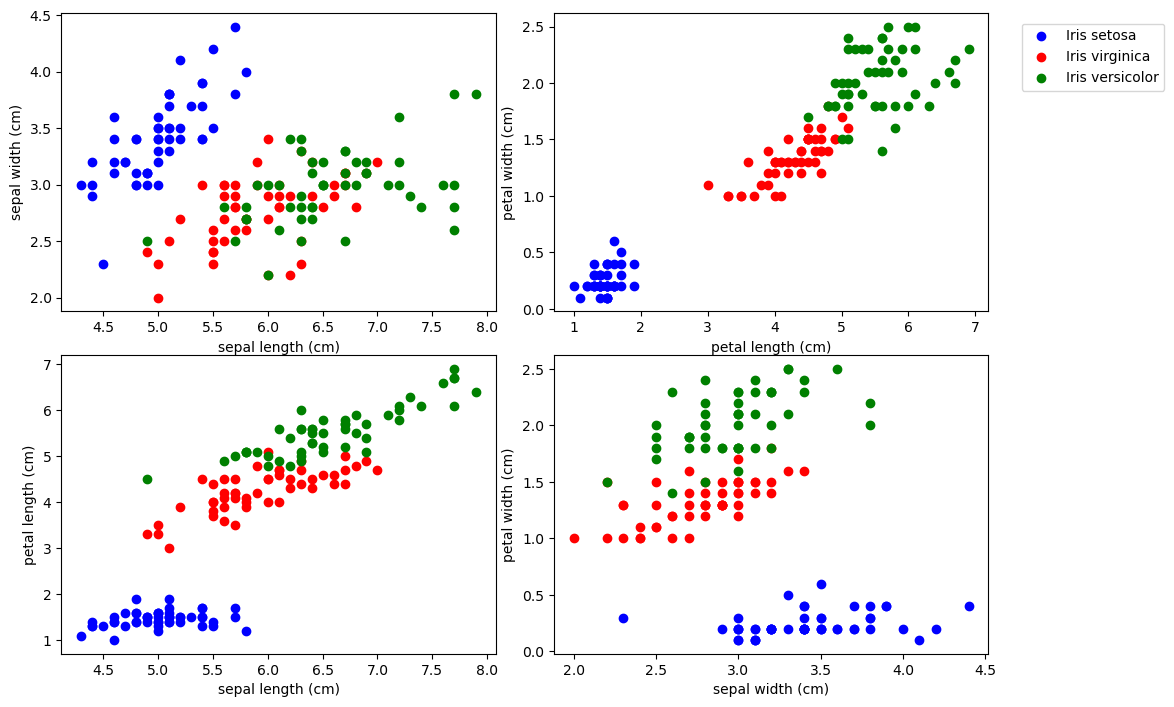

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
fig.tight_layout()

plots = [(0,1),(2,3),(0,2),(1,3)]
colors = ['b', 'r', 'g']
labels = ['Iris setosa','Iris virginica','Iris versicolor']

for i, ax in enumerate(axes.flat):
    for j in range(3):
        x = df.columns[plots[i][0]]
        y = df.columns[plots[i][1]]
        ax.scatter(df[df['target']==j][x], df[df['target']==j][y], color=colors[j])
        ax.set(xlabel=x, ylabel=y)

fig.legend(labels=labels, loc=3, bbox_to_anchor=(1.0,0.85))
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(df.drop('target',axis=1).values,
                                                    df['target'].values, test_size=0.2,
                                                    random_state=33)

X_train = torch.FloatTensor(train_X)
X_test = torch.FloatTensor(test_X)
y_train = torch.LongTensor(train_y).reshape(-1, 1)
y_test = torch.LongTensor(test_y).reshape(-1, 1)

In [11]:
print(f'Training size: {len(y_train)}')
labels, counts = y_train.unique(return_counts=True)
print(f'Labels: {labels}\nCounts: {counts}')

Training size: 120
Labels: tensor([0, 1, 2])
Counts: tensor([42, 42, 36])


In [22]:
X_train.size()

torch.Size([120, 4])

In [43]:
from torch.utils.data import TensorDataset,DataLoader

data = df.drop('target',axis=1).values
labels = df['target'].values

iris = TensorDataset(torch.FloatTensor(data),torch.FloatTensor(labels))

In [45]:
len(iris)

150

In [46]:
type(iris)

torch.utils.data.dataset.TensorDataset

In [57]:
for i in iris:
    print(i)

(tensor([5.1000, 3.5000, 1.4000, 0.2000]), tensor(0.))
(tensor([4.9000, 3.0000, 1.4000, 0.2000]), tensor(0.))
(tensor([4.7000, 3.2000, 1.3000, 0.2000]), tensor(0.))
(tensor([4.6000, 3.1000, 1.5000, 0.2000]), tensor(0.))
(tensor([5.0000, 3.6000, 1.4000, 0.2000]), tensor(0.))
(tensor([5.4000, 3.9000, 1.7000, 0.4000]), tensor(0.))
(tensor([4.6000, 3.4000, 1.4000, 0.3000]), tensor(0.))
(tensor([5.0000, 3.4000, 1.5000, 0.2000]), tensor(0.))
(tensor([4.4000, 2.9000, 1.4000, 0.2000]), tensor(0.))
(tensor([4.9000, 3.1000, 1.5000, 0.1000]), tensor(0.))
(tensor([5.4000, 3.7000, 1.5000, 0.2000]), tensor(0.))
(tensor([4.8000, 3.4000, 1.6000, 0.2000]), tensor(0.))
(tensor([4.8000, 3.0000, 1.4000, 0.1000]), tensor(0.))
(tensor([4.3000, 3.0000, 1.1000, 0.1000]), tensor(0.))
(tensor([5.8000, 4.0000, 1.2000, 0.2000]), tensor(0.))
(tensor([5.7000, 4.4000, 1.5000, 0.4000]), tensor(0.))
(tensor([5.4000, 3.9000, 1.3000, 0.4000]), tensor(0.))
(tensor([5.1000, 3.5000, 1.4000, 0.3000]), tensor(0.))
(tensor([5

In [58]:
iris_loader = DataLoader(iris, batch_size=105, shuffle=True)

In [60]:
iris_loader

In [62]:
for i_batch, sample_batched in enumerate(iris_loader):
    print(i_batch, sample_batched)

0 [tensor([[5.7000, 2.8000, 4.1000, 1.3000],
        [6.1000, 3.0000, 4.9000, 1.8000],
        [5.6000, 2.7000, 4.2000, 1.3000],
        [6.1000, 2.9000, 4.7000, 1.4000],
        [4.6000, 3.4000, 1.4000, 0.3000],
        [5.6000, 3.0000, 4.1000, 1.3000],
        [6.8000, 3.0000, 5.5000, 2.1000],
        [6.3000, 2.7000, 4.9000, 1.8000],
        [5.5000, 4.2000, 1.4000, 0.2000],
        [6.3000, 2.5000, 4.9000, 1.5000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [4.6000, 3.6000, 1.0000, 0.2000],
        [6.5000, 2.8000, 4.6000, 1.5000],
        [5.0000, 3.6000, 1.4000, 0.2000],
        [4.6000, 3.2000, 1.4000, 0.2000],
        [6.7000, 3.1000, 5.6000, 2.4000],
        [6.0000, 2.9000, 4.5000, 1.5000],
        [7.2000, 3.0000, 5.8000, 1.6000],
        [5.7000, 2.9000, 4.2000, 1.3000],
        [6.2000, 2.8000, 4.8000, 1.8000],
        [6.2000, 2.9000, 4.3000, 1.3000],
        [6.9000, 3.1000, 5.1000, 2.3000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [6.4000, 3.2000, 5.3000

In [64]:
next(iter(iris_loader))

[tensor([[7.9000, 3.8000, 6.4000, 2.0000],
         [6.1000, 2.8000, 4.0000, 1.3000],
         [6.0000, 3.0000, 4.8000, 1.8000],
         [5.8000, 2.7000, 5.1000, 1.9000],
         [6.7000, 3.3000, 5.7000, 2.5000],
         [7.1000, 3.0000, 5.9000, 2.1000],
         [6.0000, 2.2000, 4.0000, 1.0000],
         [6.5000, 3.0000, 5.5000, 1.8000],
         [4.8000, 3.1000, 1.6000, 0.2000],
         [4.9000, 2.4000, 3.3000, 1.0000],
         [4.6000, 3.1000, 1.5000, 0.2000],
         [5.7000, 4.4000, 1.5000, 0.4000],
         [6.9000, 3.2000, 5.7000, 2.3000],
         [5.1000, 3.3000, 1.7000, 0.5000],
         [5.7000, 2.8000, 4.1000, 1.3000],
         [7.7000, 3.8000, 6.7000, 2.2000],
         [6.7000, 3.0000, 5.0000, 1.7000],
         [5.0000, 2.3000, 3.3000, 1.0000],
         [6.9000, 3.1000, 4.9000, 1.5000],
         [5.5000, 2.6000, 4.4000, 1.2000],
         [6.4000, 3.1000, 5.5000, 1.8000],
         [5.7000, 2.9000, 4.2000, 1.3000],
         [6.5000, 3.0000, 5.2000, 2.0000],
         [7